# Kreuztabelle – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/kreuztabelle)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Eine **Kreuztabelle** (auch: Kontingenztafel) zeigt, wie oft die Kombinationen der
Ausprägungen **zweier kategorialer Variablen** gemeinsam auftreten.

| Begriff | Bedeutung |
|---|---|
| **Zellen** | Häufigkeit einer bestimmten Merkmalskombination |
| **Zeilensumme** | Gesamthäufigkeit einer Ausprägung der Zeilenvariable |
| **Spaltensumme** | Gesamthäufigkeit einer Ausprägung der Spaltenvariable |
| **Randhäufigkeiten** | Zeilen- und Spaltensummen zusammen |
| **Gesamtsumme (n)** | Anzahl aller Beobachtungen |

**Typische Anwendungen:**
- Welche Versicherung wird von welcher Altersgruppe bevorzugt?
- Unterscheiden sich Automarken in Stadt und Land?
- Gibt es einen Zusammenhang zwischen Geschlecht und Schirmnutzung?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Beispiel-Datensatz (numiqo)

Eine Studentin zählt an einem regnerischen Tag, wie viele Personen **mit** und wie
viele **ohne Regenschirm** in die Statistik-Vorlesung kommen – und notiert zusätzlich
das **Geschlecht**.

| Geschlecht | Schirm mit dabei |
|---|---|
| weiblich | ja |
| männlich | ja |
| weiblich | ja |
| weiblich | ja |
| männlich | ja |
| männlich | nein |
| weiblich | nein |
| ... | ... |

→ 22 Beobachtungen, 2 Variablen (Geschlecht & Schirmnutzung)

In [10]:
# numiqo-Datensatz: Geschlecht & Schirmnutzung
geschlecht = pd.Series([
    "weiblich","männlich","weiblich","weiblich","männlich","männlich",
    "weiblich","männlich","weiblich","weiblich","männlich","weiblich",
    "männlich","weiblich","männlich","männlich","männlich","weiblich",
    "männlich","weiblich","weiblich","weiblich"
])

schirm = pd.Series([
    "ja","ja","ja","ja","ja","nein",
    "nein","nein","nein","nein","nein","ja",
    "ja","ja","ja","ja","nein","nein",
    "nein","nein","nein","nein"
])

df = pd.DataFrame({"Geschlecht": geschlecht, "Schirm_dabei": schirm})

print(f"Datensatz: {len(df)} Beobachtungen, {df.shape[1]} Variablen")
print()
print(df.to_string(index=True))

Datensatz: 22 Beobachtungen, 2 Variablen

   Geschlecht Schirm_dabei
0    weiblich           ja
1    männlich           ja
2    weiblich           ja
3    weiblich           ja
4    männlich           ja
5    männlich         nein
6    weiblich         nein
7    männlich         nein
8    weiblich         nein
9    weiblich         nein
10   männlich         nein
11   weiblich           ja
12   männlich           ja
13   weiblich           ja
14   männlich           ja
15   männlich           ja
16   männlich         nein
17   weiblich         nein
18   männlich         nein
19   weiblich         nein
20   weiblich         nein
21   weiblich         nein


## 2. Kreuztabelle mit absoluten Häufigkeiten

Die **absolute Kreuztabelle** zeigt, wie oft jede Merkmalskombination vorkommt.

**Erwartetes Ergebnis laut numiqo:**

|  | Schirm: ja | Schirm: nein | Total |
|---|---|---|---|
| **weiblich** | 5 | 7 | 12 |
| **männlich** | 5 | 5 | 10 |
| **Total** | 10 | 12 | 22 |

**Aufbau:**
- Zeilen = Ausprägungen der abhängigen Variable (Geschlecht)
- Spalten = Ausprägungen der unabhängigen Variable (Schirm)
- Randhäufigkeiten = Zeilen- und Spaltensummen

In [11]:
# Absolute Häufigkeiten – Kreuztabelle
kt_abs = pd.crosstab(
    df["Geschlecht"],
    df["Schirm_dabei"],
    margins=True,
    margins_name="Total"
)

print("Kreuztabelle: Absolute Häufigkeiten")
print(kt_abs.to_string())
print()

# Verifikation gegen numiqo
print("Verifikation:")
print(f"  weiblich & ja:    {kt_abs.loc['weiblich','ja']}   (numiqo: 5) {'+' if kt_abs.loc['weiblich','ja']==5 else '-'}")
print(f"  weiblich & nein:  {kt_abs.loc['weiblich','nein']}   (numiqo: 7) {'+' if kt_abs.loc['weiblich','nein']==7 else '-'}")
print(f"  männlich & ja:   {kt_abs.loc['männlich','ja']}   (numiqo: 5) {'+' if kt_abs.loc['männlich','ja']==5 else '-'}")
print(f"  männlich & nein: {kt_abs.loc['männlich','nein']}   (numiqo: 5) {'+' if kt_abs.loc['männlich','nein']==5 else '-'}")

Kreuztabelle: Absolute Häufigkeiten
Schirm_dabei  ja  nein  Total
Geschlecht                   
männlich       5     5     10
weiblich       5     7     12
Total         10    12     22

Verifikation:
  weiblich & ja:    5   (numiqo: 5) +
  weiblich & nein:  7   (numiqo: 7) +
  männlich & ja:   5   (numiqo: 5) +
  männlich & nein: 5   (numiqo: 5) +


## 3. Relative Häufigkeiten in der Kreuztabelle

Es gibt drei Arten von relativen Häufigkeiten:

| Art | Bezugsgröße | Formel | Frage |
|---|---|---|---|
| **Gesamtprozente** | Alle n Fälle | Zelle / n | Wie groß ist der Anteil dieser Kombination insgesamt? |
| **Zeilenprozente** | Zeilensumme | Zelle / Zeilensumme | Wie verteilt sich Variable B innerhalb jeder Gruppe von A? |
| **Spaltenprozente** | Spaltensumme | Zelle / Spaltensumme | Wie verteilt sich Variable A innerhalb jeder Kategorie von B? |

> **Tipp:** Zeilenprozente eignen sich, wenn man wissen möchte, ob sich
> zwei Gruppen (z. B. männlich/weiblich) im Verhalten unterscheiden.

In [12]:
# Alle drei Arten relativer Häufigkeiten
kt_basis = pd.crosstab(df["Geschlecht"], df["Schirm_dabei"])
n = len(df)

# Gesamtprozente
kt_gesamt = (kt_basis / n * 100).round(1)

# Zeilenprozente
kt_zeile  = kt_basis.div(kt_basis.sum(axis=1), axis=0).mul(100).round(1)

# Spaltenprozente
kt_spalte = kt_basis.div(kt_basis.sum(axis=0), axis=1).mul(100).round(1)

print("Gesamtprozente (Basis: n=22)")
print(kt_gesamt.to_string())
print()
print("Zeilenprozente (Basis: Zeilensumme)")
print(kt_zeile.to_string())
print("Interpretation: Von allen weiblichen Personen hatten 41.7% einen Schirm dabei.")
print()
print("Spaltenprozente (Basis: Spaltensumme)")
print(kt_spalte.to_string())
print("Interpretation: Von allen Personen mit Schirm waren 50.0% weiblich.")

Gesamtprozente (Basis: n=22)
Schirm_dabei    ja  nein
Geschlecht              
männlich      22.7  22.7
weiblich      22.7  31.8

Zeilenprozente (Basis: Zeilensumme)
Schirm_dabei    ja  nein
Geschlecht              
männlich      50.0  50.0
weiblich      41.7  58.3
Interpretation: Von allen weiblichen Personen hatten 41.7% einen Schirm dabei.

Spaltenprozente (Basis: Spaltensumme)
Schirm_dabei    ja  nein
Geschlecht              
männlich      50.0  41.7
weiblich      50.0  58.3
Interpretation: Von allen Personen mit Schirm waren 50.0% weiblich.


## 4. Visualisierung der Kreuztabelle

Kreuztabellen lassen sich am besten als **gruppiertes** oder **gestapeltes
Balkendiagramm** darstellen.

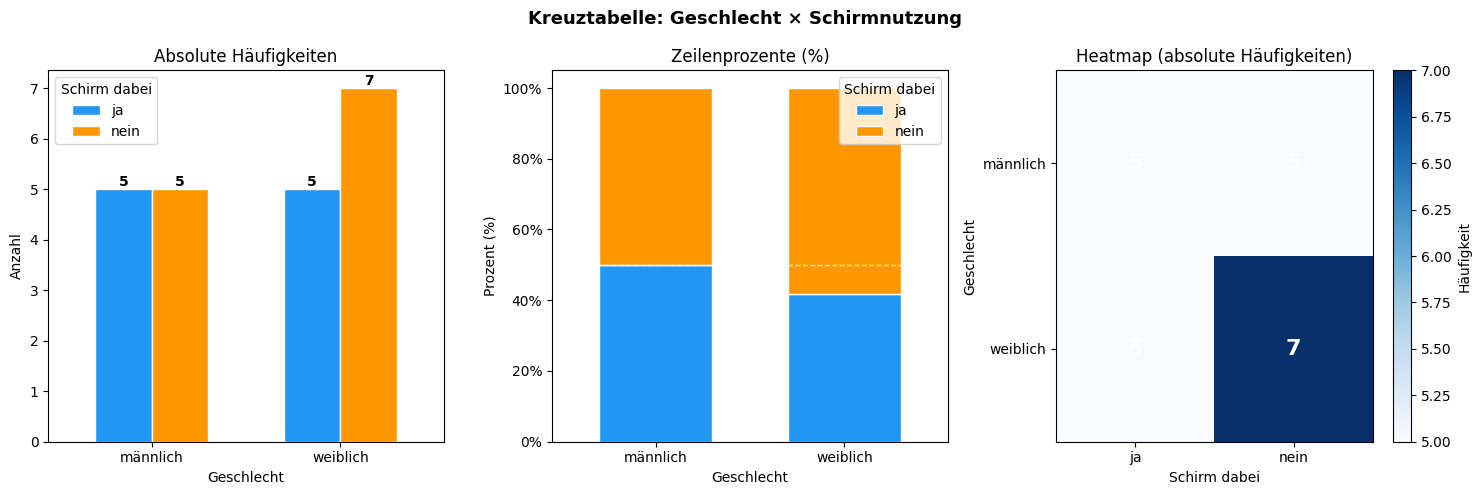

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Kreuztabelle: Geschlecht × Schirmnutzung", fontsize=13, fontweight="bold")

farben = {"ja": "#2196F3", "nein": "#FF9800"}

# 1. Absolute Häufigkeiten – gruppiert
kt_basis.plot(kind="bar", ax=axes[0], color=[farben["ja"], farben["nein"]],
              edgecolor="white", width=0.6)
axes[0].set_title("Absolute Häufigkeiten")
axes[0].set_xlabel("Geschlecht")
axes[0].set_ylabel("Anzahl")
axes[0].set_xticklabels(kt_basis.index, rotation=0)
axes[0].legend(title="Schirm dabei", labels=["ja", "nein"])
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, fontweight="bold")

# 2. Zeilenprozente – gestapelt
kt_zeile.plot(kind="bar", stacked=True, ax=axes[1],
              color=[farben["ja"], farben["nein"]], edgecolor="white", width=0.6)
axes[1].set_title("Zeilenprozente (%)")
axes[1].set_xlabel("Geschlecht")
axes[1].set_ylabel("Prozent (%)")
axes[1].set_xticklabels(kt_zeile.index, rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[1].legend(title="Schirm dabei", labels=["ja", "nein"])
axes[1].axhline(50, color="white", linestyle="--", linewidth=1, alpha=0.7)

# 3. Heatmap der absoluten Häufigkeiten
im = axes[2].imshow(kt_basis.values, cmap="Blues", aspect="auto")
axes[2].set_xticks(range(len(kt_basis.columns)))
axes[2].set_yticks(range(len(kt_basis.index)))
axes[2].set_xticklabels(kt_basis.columns)
axes[2].set_yticklabels(kt_basis.index)
axes[2].set_title("Heatmap (absolute Häufigkeiten)")
axes[2].set_xlabel("Schirm dabei")
axes[2].set_ylabel("Geschlecht")
for i in range(len(kt_basis.index)):
    for j in range(len(kt_basis.columns)):
        axes[2].text(j, i, str(kt_basis.iloc[i, j]),
                     ha="center", va="center", fontsize=16,
                     fontweight="bold", color="white" if kt_basis.iloc[i,j] > 4 else "black")
plt.colorbar(im, ax=axes[2], label="Häufigkeit")

plt.tight_layout()
plt.show()

## 5. Randhäufigkeiten und vollständige Tabelle

Eine vollständige Kreuztabelle enthält immer auch die **Randhäufigkeiten**
(Zeilen- und Spaltensummen) sowie die **Gesamtsumme n**.

In [15]:
# Vollständige Kreuztabelle mit Randhäufigkeiten und Prozenten
def kreuztabelle_vollstaendig(var1, var2, name1="Variable 1", name2="Variable 2"):
    """
    Erstellt eine vollständige Kreuztabelle mit absoluten Häufigkeiten,
    Zeilenprozenten und Spaltenprozenten.
    """
    n = len(var1)
    kt  = pd.crosstab(var1, var2, margins=True, margins_name="Total")
    kt_zp = pd.crosstab(var1, var2,
                        normalize="index").mul(100).round(1)
    kt_sp = pd.crosstab(var1, var2,
                        normalize="columns").mul(100).round(1)

    print(f"Kreuztabelle: {name1} × {name2}  (n={n})")
    print()
    print("Absolute Häufigkeiten")
    print(kt.to_string())
    print()
    print("Zeilenprozente (%)")
    print(kt_zp.to_string())
    print()
    print("Spaltenprozente (%)")
    print(kt_sp.to_string())
    return kt

kt_voll = kreuztabelle_vollstaendig(
    df["Geschlecht"], df["Schirm_dabei"],
    "Geschlecht", "Schirm dabei"
)

Kreuztabelle: Geschlecht × Schirm dabei  (n=22)

Absolute Häufigkeiten
Schirm_dabei  ja  nein  Total
Geschlecht                   
männlich       5     5     10
weiblich       5     7     12
Total         10    12     22

Zeilenprozente (%)
Schirm_dabei    ja  nein
Geschlecht              
männlich      50.0  50.0
weiblich      41.7  58.3

Spaltenprozente (%)
Schirm_dabei    ja  nein
Geschlecht              
männlich      50.0  41.7
weiblich      50.0  58.3


## 6. Von der Kreuztabelle zum Chi-Quadrat-Test

Eine Kreuztabelle gehört zur **deskriptiven Statistik** – sie beschreibt nur
die vorliegende Stichprobe.

Um zu prüfen, ob der beobachtete Zusammenhang auch in der **Grundgesamtheit** gilt
(Inferenzstatistik), wird der **Chi-Quadrat-Test (χ²-Test)** eingesetzt.

**Hypothesen:**
- **H₀:** Es gibt keinen Zusammenhang zwischen den zwei Variablen (Unabhängigkeit)
- **H₁:** Es gibt einen Zusammenhang zwischen den zwei Variablen

**Entscheidungsregel:** Wenn p < 0,05 → H₀ ablehnen → signifikanter Zusammenhang

In [21]:
# Chi-Quadrat-Test auf Basis der Kreuztabelle
kt_test = pd.crosstab(df["Geschlecht"], df["Schirm_dabei"])

chi2, p_wert, df_chi, erwartete = chi2_contingency(kt_test)

print("Chi-Quadrat-Test: Geschlecht × Schirm dabei")
print(f"Chi-Quadrat (chi2): {chi2:.4f}")
print(f"p-Wert:             {p_wert:.4f}")
print(f"Freiheitsgrade:     {df_chi}")
print()
print("Erwartete Häufigkeiten (unter H0: Unabhängigkeit):")
print(pd.DataFrame(erwartete.round(2),
                   index=kt_test.index,
                   columns=kt_test.columns).to_string())
print()

alpha = 0.05
if p_wert < alpha:
    print(f"Ergebnis: p={p_wert:.4f} < {alpha} → H₀ ablehnen → signifikanter Zusammenhang")
else:
    print(f"Ergebnis: p={p_wert:.4f} >= {alpha} → H₀ nicht ablehnen → kein signifikanter Zusammenhang")
print()
print("Hinweis: Die Kreuztabelle beschreibt nur die Stichprobe.")
print("Für Aussagen über die Grundgesamtheit wird der Chi-Quadrat-Test benötigt.")

Chi-Quadrat-Test: Geschlecht × Schirm dabei
Chi-Quadrat (chi2): 0.0000
p-Wert:             1.0000
Freiheitsgrade:     1

Erwartete Häufigkeiten (unter H0: Unabhängigkeit):
Schirm_dabei    ja  nein
Geschlecht              
männlich      4.55  5.45
weiblich      5.45  6.55

Ergebnis: p=1.0000 >= 0.05 → H₀ nicht ablehnen → kein signifikanter Zusammenhang

Hinweis: Die Kreuztabelle beschreibt nur die Stichprobe.
Für Aussagen über die Grundgesamtheit wird der Chi-Quadrat-Test benötigt.


## 7. Weiteres Beispiel: Versicherung nach Altersgruppe

**Fragestellung:** Welche Versicherung wird von welcher Altersgruppe bevorzugt?

Dies ist ein typisches Marktforschungs-Beispiel für Kreuztabellen.

Absolute Häufigkeiten: Versicherung × Altersgruppe
Versicherung  Bank  Makler  Online  Total
Altersgruppe                             
18-30           11      12      26     49
31-50            7      13      20     40
51+              9      16       6     31
Total           27      41      52    120

Zeilenprozente (%)
Versicherung  Bank  Makler  Online
Altersgruppe                      
18-30         22.4    24.5    53.1
31-50         17.5    32.5    50.0
51+           29.0    51.6    19.4

Interpretation: Jüngere (18-30) bevorzugen Online-Versicherungen stärker.


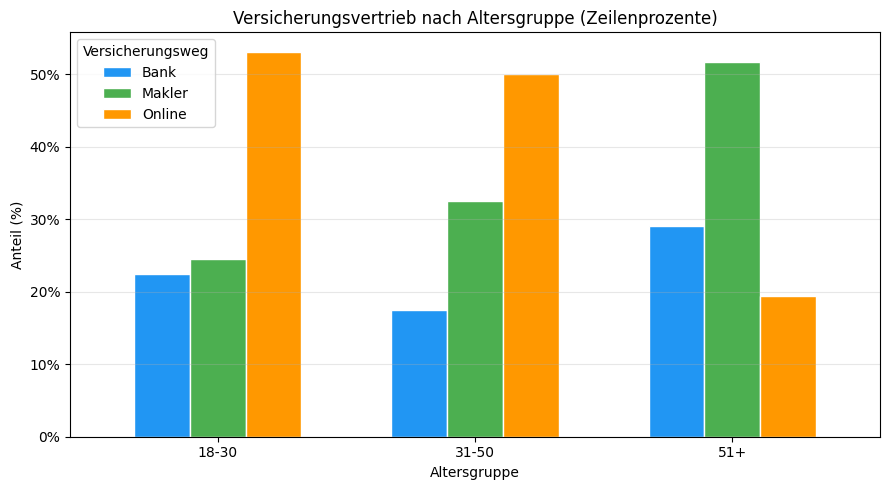

In [19]:
# Marktforschungs-Beispiel: Versicherung × Altersgruppe
np.random.seed(42)

altersgruppen = np.random.choice(["18-30", "31-50", "51+"], size=120,
                                  p=[0.35, 0.40, 0.25])
versicherung  = []
for alter in altersgruppen:
    if alter == "18-30":
        versicherung.append(np.random.choice(["Online", "Makler", "Bank"],
                                              p=[0.55, 0.25, 0.20]))
    elif alter == "31-50":
        versicherung.append(np.random.choice(["Online", "Makler", "Bank"],
                                              p=[0.35, 0.40, 0.25]))
    else:
        versicherung.append(np.random.choice(["Online", "Makler", "Bank"],
                                              p=[0.20, 0.45, 0.35]))

df2 = pd.DataFrame({
    "Altersgruppe": altersgruppen,
    "Versicherung":  versicherung
})

kt_markt = pd.crosstab(df2["Altersgruppe"], df2["Versicherung"],
                       margins=True, margins_name="Total")
kt_markt_zp = pd.crosstab(df2["Altersgruppe"], df2["Versicherung"],
                           normalize="index").mul(100).round(1)

print("Absolute Häufigkeiten: Versicherung × Altersgruppe")
print(kt_markt.to_string())
print()
print("Zeilenprozente (%)")
print(kt_markt_zp.to_string())
print()
print("Interpretation: Jüngere (18-30) bevorzugen Online-Versicherungen stärker.")

# Visualisierung
fig, ax = plt.subplots(figsize=(9, 5))
kt_markt_zp.plot(kind="bar", ax=ax,
                 color=["#2196F3", "#4CAF50", "#FF9800"],
                 edgecolor="white", width=0.65)
ax.set_title("Versicherungsvertrieb nach Altersgruppe (Zeilenprozente)")
ax.set_xlabel("Altersgruppe")
ax.set_ylabel("Anteil (%)")
ax.set_xticklabels(kt_markt_zp.index, rotation=0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(title="Versicherungsweg")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Zusammenfassung

```
Kreuztabelle – Übersicht
│
├── DEFINITION
│   └── Häufigkeiten der Kombinationen zweier kategorialer Variablen
│
├── AUFBAU
│   ├── Zeilen       = Ausprägungen Variable 1 (abhängig)
│   ├── Spalten      = Ausprägungen Variable 2 (unabhängig)
│   ├── Zellen       = Häufigkeit der Merkmalskombination
│   └── Randhäuf.    = Zeilen- und Spaltensummen
│
├── ARTEN DER HÄUFIGKEITEN
│   ├── Absolut          → Anzahl je Zelle
│   ├── Gesamtprozente   → Zelle / n × 100
│   ├── Zeilenprozente   → Zelle / Zeilensumme × 100  ← häufig
│   └── Spaltenprozente  → Zelle / Spaltensumme × 100
│
├── ANWENDUNG
│   ├── 2 kategoriale Variablen
│   ├── Deskriptiv: Zusammenhang in der Stichprobe beschreiben
│   └── Marktforschung, Umfrageauswertung, Sozialwissenschaften
│
└── SIGNIFIKANZTEST
    └── Chi-Quadrat-Test (χ²) → Zusammenhang in der Grundgesamtheit prüfen
        H₀: kein Zusammenhang (Unabhängigkeit)
        H₁: Zusammenhang vorhanden
        p < 0.05 → signifikant
```

---
Quelle: [numiqo.de/tutorial/kreuztabelle](https://numiqo.de/tutorial/kreuztabelle)